# Experiment 1

Setting default log level to "

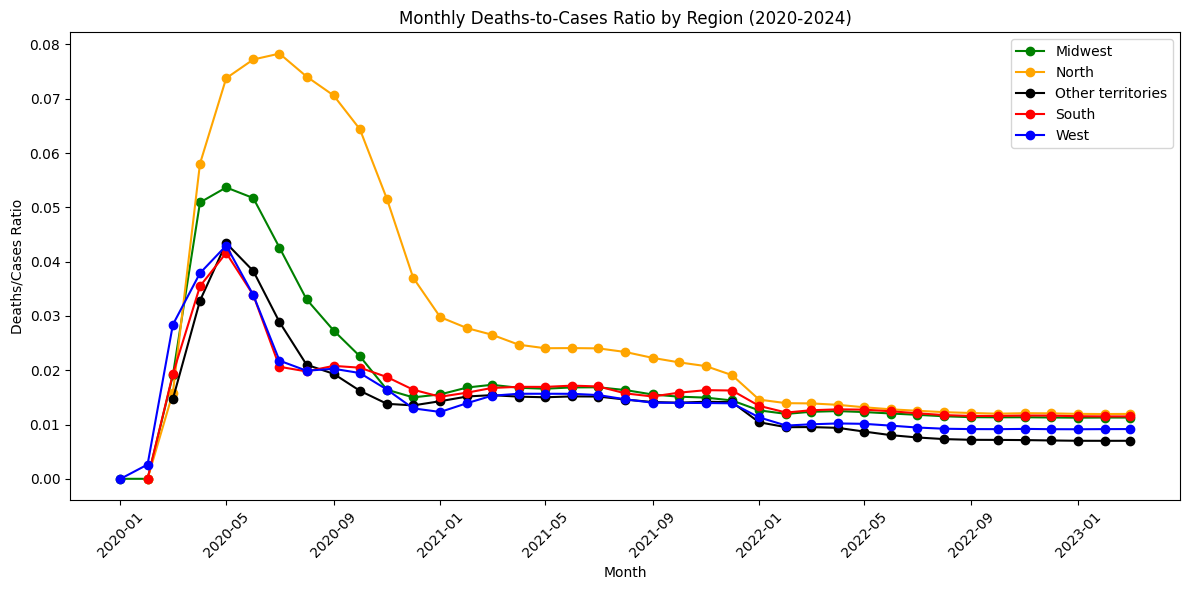

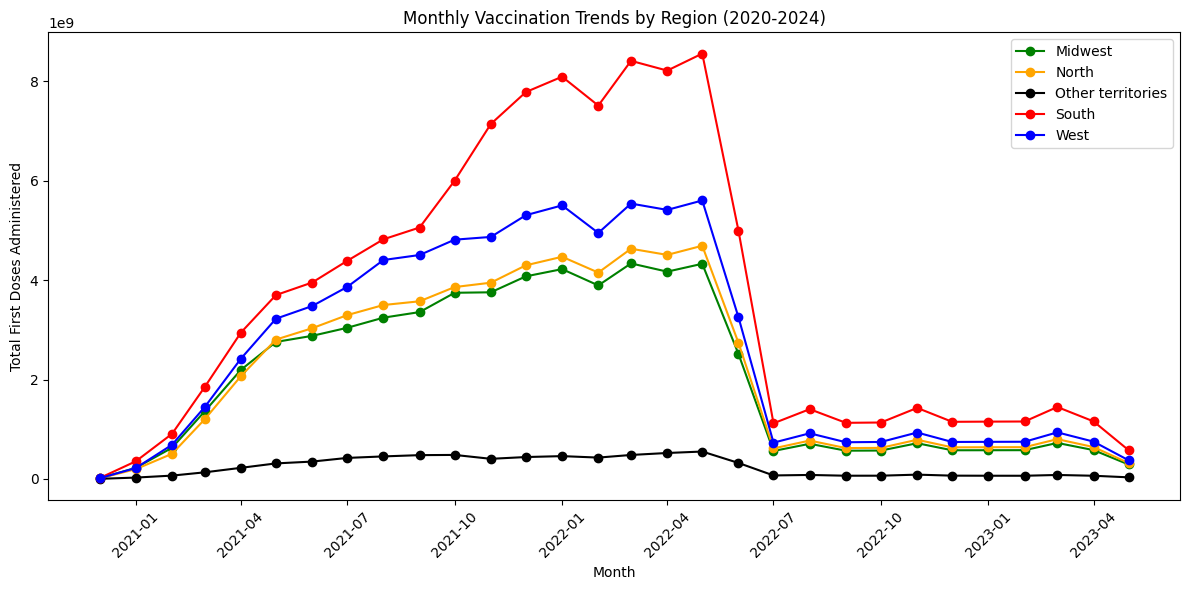

Total Execution Time: 146.54 seconds


In [1]:
import time
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.sql.types import StringType
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from operator import add

start_time = time.time()

spark = SparkSession.builder \
    .master("spark://192.168.2.213:7077") \
    .appName("hasnain_project_experiment1_6cores") \
    .config("spark.driver.host", "192.168.2.70") \
    .config("spark.driver.port", "4041") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.dynamicAllocation.executorIdleTimeout", "60s") \
    .config("spark.cores.max", "6") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.instances", "3") \
    .config("spark.executor.memory", "1G") \
    .config("spark.driver.memory", "1G") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.ui.host", "0.0.0.0") \
    .config("spark.ui.enabled", "true") \
    .getOrCreate()


spark_context = spark.sparkContext
spark_context.setLogLevel("ERROR")


# Mapping from state abbreviation to full state name 
state_mapping = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming", "GU": "Guam", "PR": "Puerto Rico",
    "MP": "Northern Mariana Islands", "PW": "Palau"
}

# Creating reverse mapping
full_to_abbr = {v: k for k, v in state_mapping.items()}

us_regions = {
    "West": ["WA", "OR", "CA", "NV", "ID", "UT", "AZ", "NM", "CO", "AK", "HI"],
    "South": ["TX", "OK", "AR", "LA", "MS", "AL", "GA", "FL", "SC", "NC", "TN", "KY", "WV", "VA", "MD", "DE"],
    "Midwest": ["ND", "SD", "NE", "KS", "MN", "IA", "MO", "WI", "IL", "IN", "MI", "OH"],
    "North": ["NY", "PA", "NJ", "CT", "RI", "MA", "VT", "NH", "ME"]
}

# Create mapping from state abbreviation to region
state_to_region = {}
for region, states in us_regions.items():
    for st in states:
        state_to_region[st] = region

# Broadcast the dictionaries for efficiency
bc_full_to_abbr = spark_context.broadcast(full_to_abbr)
bc_state_to_region = spark_context.broadcast(state_to_region)


def full_to_abbr_udf(state_full):
    return bc_full_to_abbr.value.get(state_full, None)
udf_full_to_abbr = F.udf(full_to_abbr_udf, StringType())


def state_to_region_udf(state_abbr):
    return bc_state_to_region.value.get(state_abbr, "Other territories")
udf_state_to_region = F.udf(state_to_region_udf, StringType())



covid_path = "hdfs://192.168.2.213:9000/data/us-counties-*.csv"
covid_df = spark.read.csv(covid_path, header=True, inferSchema=True)
covid_df = covid_df.withColumn("date", F.to_date(F.col("date"), "yyyy-MM-dd")) \
                   .withColumn("year", F.year("date")) \
                   .withColumn("month", F.month("date")) \
                   .withColumn("year_month", F.date_format(F.col("date"), "yyyy-MM")) \
                   .filter((F.col("year") >= 2020) & (F.col("year") <= 2024))


covid_df = covid_df.withColumn("state_abbr", udf_full_to_abbr(F.col("state")))

covid_df = covid_df.withColumn("region", udf_state_to_region(F.col("state_abbr")))

covid_agg = covid_df.groupBy("region", "year_month") \
    .agg(
        F.sum("cases").alias("total_cases"),
        F.sum("deaths").alias("total_deaths")
    ) \
    .withColumn("deaths_cases_ratio",
                F.when(F.col("total_cases") > 0, F.col("total_deaths") / F.col("total_cases"))
                 .otherwise(0)) \
    .orderBy("year_month")

covid_pd = covid_agg.toPandas()

covid_pd["year_month_dt"] = pd.to_datetime(covid_pd["year_month"] + "-01")


vacc_path = "hdfs://192.168.2.213:9000/data/vaccination-counties.csv"
vacc_df = spark.read.csv(vacc_path, header=True, inferSchema=True)

vacc_df = vacc_df.withColumn("Date", F.to_date(F.col("Date"), "MM/dd/yyyy")) \
                 .withColumn("year", F.year("Date")) \
                 .withColumn("month", F.month("Date")) \
                 .withColumn("year_month", F.date_format(F.col("Date"), "yyyy-MM")) \
                 .filter((F.col("year") >= 2020) & (F.col("year") <= 2024))


vacc_df = vacc_df.withColumn("region", udf_state_to_region(F.col("Recip_State")))
vacc_agg = vacc_df.groupBy("region", "year_month") \
    .agg(
        F.sum("Administered_Dose1_Recip").alias("total_dose1_administered")
    ) \
    .orderBy("year_month")

covid_agg.write.mode("overwrite").csv("hdfs://192.168.2.213:9000/data/aggregated_covid_results")
vacc_agg.write.mode("overwrite").csv("hdfs://192.168.2.213:9000/data/aggregated_vaccination_results")

vacc_pd = vacc_agg.toPandas()
vacc_pd["year_month_dt"] = pd.to_datetime(vacc_pd["year_month"] + "-01")

color_mapping = {
    "West": "blue",
    "South": "red",
    "Midwest": "green",
    "North": "orange",
    "Other Regions": "purple"
}

# Plot 1: Monthly Deaths/Cases Ratio per Region (COVID data)
plt.figure(figsize=(12, 6))
for region in sorted(covid_pd["region"].unique()):
    region_data = covid_pd[covid_pd["region"] == region]
    color = color_mapping.get(region, "black")  # default to black if region not found
    plt.plot(region_data["year_month_dt"], region_data["deaths_cases_ratio"],
             marker='o', label=region, color=color)
plt.xlabel("Month")
plt.ylabel("Deaths/Cases Ratio")
plt.title("Monthly Deaths-to-Cases Ratio by Region (2020-2024)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("covid_deaths_cases_ratio_by_region.png")
plt.show()

# Plot 2: Monthly Vaccination Trends per Region (Vaccination data)
plt.figure(figsize=(12, 6))
for region in sorted(vacc_pd["region"].unique()):
    region_data = vacc_pd[vacc_pd["region"] == region]
    color = color_mapping.get(region, "black")  # default to black if region not found
    plt.plot(region_data["year_month_dt"], region_data["total_dose1_administered"],
             marker='o', label=region, color=color)
plt.xlabel("Month")
plt.ylabel("Total First Doses Administered")
plt.title("Monthly Vaccination Trends by Region (2020-2024)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("vaccination_trends_by_region.png")
plt.show()


# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print("Total Execution Time: {:.2f} seconds".format(elapsed_time))
spark.stop()

## Test 1.1: Strong scalability

### Run 1

.config("spark.cores.max", "2") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "1") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \

Total Execution Time: 125.88 seconds

### Run 2

.config("spark.cores.max", "4") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "2") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \

Total Execution Time: 85.27 seconds

### Run 3

.config("spark.cores.max", "6") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "3") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \

Total Execution Time: 70.05 seconds

## Test 1.2: Weak scalability

### Run 1

.config("spark.cores.max", "2") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "1") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \

Total Execution Time: 68.21 seconds

### Run 2: With 2x synthetic dataset

.config("spark.cores.max", "4") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "2") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \

Total Execution Time: 80.71 seconds

### Run 3: With 3x synthetic dataset

.config("spark.cores.max", "6") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "3") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \

Total Execution Time: 91.23 seconds


In [2]:
import sys
import time
from pyspark.sql import SparkSession, functions as F

dup_factor = 3

spark = SparkSession.builder \
    .master("spark://192.168.2.213:7077") \
    .appName(f"DuplicateData_{dup_factor}x") \
    .config("spark.driver.host", "192.168.2.70") \
    .config("spark.driver.port", "4041") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

# Function to duplicate a DataFrame by unioning it with itself dup_factor times
def duplicate_df(df, factor):
    duplicated_df = df
    for i in range(factor - 1):
        duplicated_df = duplicated_df.union(df)
    return duplicated_df

covid_input_path = "hdfs://192.168.2.213:9000/data/us-counties-*.csv"
covid_df = spark.read.csv(covid_input_path, header=True, inferSchema=True)
print(f"Original COVID data row count: {covid_df.count()}")

duplicated_covid_df = duplicate_df(covid_df, dup_factor)
print(f"Duplicated COVID data row count: {duplicated_covid_df.count()}")

covid_output_path = f"hdfs://192.168.2.213:9000/data/synthetic/us-counties-{dup_factor}x.csv"
duplicated_covid_df.write.mode("overwrite").csv(covid_output_path, header=True)
print(f"Duplicated COVID data written to {covid_output_path}")

vacc_input_path = "hdfs://192.168.2.213:9000/data/vaccination-counties.csv"
vacc_df = spark.read.csv(vacc_input_path, header=True, inferSchema=True)
print(f"Original Vaccination data row count: {vacc_df.count()}")

duplicated_vacc_df = duplicate_df(vacc_df, dup_factor)
print(f"Duplicated Vaccination data row count: {duplicated_vacc_df.count()}")

vacc_output_path = f"hdfs://192.168.2.213:9000/data/synthetic/vaccination-counties-{dup_factor}x.csv"
duplicated_vacc_df.write.mode("overwrite").csv(vacc_output_path, header=True)
print(f"Duplicated Vaccination data written to {vacc_output_path}")


Original COVID data row count: 3622862
Duplicated COVID data row count: 10868586
Duplicated COVID data written to hdfs://192.168.2.213:9000/data/synthetic/us-counties-3x.csv
Original Vaccination data row count: 1962781
Duplicated Vaccination data row count: 5888343
Duplicated Vaccination data written to hdfs://192.168.2.213:9000/data/synthetic/vaccination-counties-3x.csv
Total Execution Time: 88.31 seconds


# Experiment 2

In [1]:
import time
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import StringType
from pyspark.sql.window import Window


# Start timing
start_time = time.time()

spark = SparkSession.builder \
    .master("spark://192.168.2.213:7077") \
    .appName("hasnain_project_experiment2_6cores") \
    .config("spark.driver.host", "192.168.2.70") \
    .config("spark.driver.port", "4041") \
    .config("spark.dynamicAllocation.enabled", "false") \
    .config("spark.dynamicAllocation.executorIdleTimeout", "60s") \
    .config("spark.cores.max", "6") \
    .config("spark.executor.cores", "2") \
    .config("spark.executor.instances", "3") \
    .config("spark.executor.memory", "1G") \
    .config("spark.driver.memory", "1G") \
    .config("spark.sql.shuffle.partitions", "200") \
    .config("spark.ui.host", "0.0.0.0") \
    .config("spark.ui.enabled", "true") \
    .getOrCreate()

spark_context = spark.sparkContext
spark_context.setLogLevel("ERROR")


# 1. Helper: State Mapping and UDF

state_mapping = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota", "MS": "Mississippi",
    "MO": "Missouri", "MT": "Montana", "NE": "Nebraska", "NV": "Nevada",
    "NH": "New Hampshire", "NJ": "New Jersey", "NM": "New Mexico", "NY": "New York",
    "NC": "North Carolina", "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma",
    "OR": "Oregon", "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington", "WV": "West Virginia",
    "WI": "Wisconsin", "WY": "Wyoming", "GU": "Guam", "PR": "Puerto Rico",
    "MP": "Northern Mariana Islands", "PW": "Palau"
}

full_to_abbr = {v: k for k, v in state_mapping.items()}
bc_full_to_abbr = spark_context.broadcast(full_to_abbr)
udf_full_to_abbr = F.udf(lambda state: bc_full_to_abbr.value.get(state, None), StringType())


# 2. Processing the COVID‑19 Dataset

covid_path = "hdfs://192.168.2.213:9000/data/us-counties-*.csv"
covid_df = spark.read.csv(covid_path, header=True, inferSchema=True)

covid_df = (covid_df.withColumn("date", F.to_date(F.col("date"), "yyyy-MM-dd"))
            .withColumn("year", F.year("date"))
            .withColumn("week", F.weekofyear("date"))
            .filter((F.col("year") >= 2020) & (F.col("year") <= 2024) & (F.col("week") != 53))
            .withColumn("state_abbr", udf_full_to_abbr(F.col("state")))
           )

covid_weekly = (covid_df.groupBy("state_abbr", "year", "week")
                .agg(F.max("cases").alias("cum_cases"))
               )
w_covid = Window.partitionBy("state_abbr").orderBy("year", "week")
covid_weekly = (covid_weekly
                .withColumn("prev_cum_cases", F.lag("cum_cases").over(w_covid))
                .withColumn("new_cases", F.when(F.col("prev_cum_cases").isNull(), F.col("cum_cases"))
                            .otherwise(F.col("cum_cases") - F.col("prev_cum_cases")))
                .withColumn("new_cases", F.when(F.col("new_cases") < 0, 0).otherwise(F.col("new_cases")))
                .orderBy("state_abbr", "year", "week")
               )


# 3. Processing the Vaccination Dataset

vacc_path = "hdfs://192.168.2.213:9000/data/vaccination-counties.csv"
vacc_df = spark.read.csv(vacc_path, header=True, inferSchema=True)

vacc_df = (vacc_df.withColumn("Date", F.to_date(F.col("Date"), "MM/dd/yyyy"))
           .withColumn("year", F.year("Date"))
           .withColumn("week", F.col("MMWR_week"))
           .filter((F.col("year") >= 2020) & (F.col("year") <= 2024) & (F.col("week") != 53))
           .withColumnRenamed("Recip_State", "state_abbr")
          )

vacc_weekly = (vacc_df.groupBy("state_abbr", "year", "week")
                .agg(
                    F.max("Administered_Dose1_Recip").alias("cum_dose1"),
                    F.max("Series_Complete_Yes").alias("cum_complete"),
                    F.max("Booster_Doses").alias("cum_booster")
                )
               )
w_vacc = Window.partitionBy("state_abbr").orderBy("year", "week")
vacc_weekly = (vacc_weekly
               .withColumn("prev_cum_dose1", F.lag("cum_dose1").over(w_vacc))
               .withColumn("new_dose1", F.when(F.col("prev_cum_dose1").isNull(), F.col("cum_dose1"))
                           .otherwise(F.col("cum_dose1") - F.col("prev_cum_dose1")))
               .withColumn("prev_cum_complete", F.lag("cum_complete").over(w_vacc))
               .withColumn("new_complete", F.when(F.col("prev_cum_complete").isNull(), F.col("cum_complete"))
                           .otherwise(F.col("cum_complete") - F.col("prev_cum_complete")))
               .withColumn("prev_cum_booster", F.lag("cum_booster").over(w_vacc))
               .withColumn("new_booster", F.when(F.col("prev_cum_booster").isNull(), F.col("cum_booster"))
                           .otherwise(F.col("cum_booster") - F.col("prev_cum_booster")))
               .orderBy("state_abbr", "year", "week")
              )



# 4. Creating the Combined Dataset

combined_df = (covid_weekly.join(
    vacc_weekly.select("state_abbr", "year", "week", "new_dose1", "new_complete", "new_booster"),
    on=["state_abbr", "year", "week"],
    how="inner")
    .na.drop()
    .cache()
)


# 5. Cleaning
# Although there is a valid surge of vaccinations in certain period but this surge dirupts the 
# overall analysis, thats why I have resolved this by capping the surge value to mean+3*std


cols_to_clean = ["new_cases", "new_dose1", "new_complete", "new_booster"]

# Compute mean and std for all columns at once.
agg_exprs = []
for col in cols_to_clean:
    agg_exprs.append(F.mean(col).alias(f"{col}_mean"))
    agg_exprs.append(F.stddev(col).alias(f"{col}_std"))
stats = combined_df.agg(*agg_exprs).collect()[0]

for col in cols_to_clean:
    mean_val = stats[f"{col}_mean"]
    std_val = stats[f"{col}_std"]
    upper_bound = mean_val + 3 * std_val
    print(f"{col}: mean={mean_val}, std={std_val}, upper_bound={upper_bound}")
    combined_df = combined_df.withColumn(
        col,
        F.when(F.col(col) < 0, 0).otherwise(
            F.when(F.col(col) > upper_bound, upper_bound).otherwise(F.col(col))
        )
    )


for col in ["new_dose1", "new_complete", "new_booster"]:
    corr_val = combined_df.stat.corr("new_cases", col)
    print("Correlation between new_cases and {}: {:.3f}".format(col, corr_val))

# 6. Introducing a 12-Week Lag for Vaccination Metrics
# This is to verify whether vaccinations have had an affect on the new cases or not

w_combined = Window.partitionBy("state_abbr").orderBy("year", "week")
combined_df = (combined_df
               .withColumn("new_dose1_lag", F.lag("new_dose1", 12).over(w_combined))
               .withColumn("new_complete_lag", F.lag("new_complete", 12).over(w_combined))
               .withColumn("new_booster_lag", F.lag("new_booster", 12).over(w_combined))
              )
combined_df = combined_df.na.drop(subset=["new_dose1_lag", "new_complete_lag", "new_booster_lag"])

for col in ["new_dose1_lag", "new_complete_lag", "new_booster_lag"]:
    corr_val = combined_df.stat.corr("new_cases", col)
    print("Correlation between new_cases and {}: {:.3f}".format(col, corr_val))



spark.stop()
end_time = time.time()
print("Total Execution Time: {:.2f} seconds".format(end_time - start_time))


Setting default log level to "

new_cases: mean=3746.003444316877, std=13874.847977449941, upper_bound=45370.5473766667
new_dose1: mean=1601.8427095292766, std=56014.348525089124, upper_bound=169644.88828479665
new_complete: mean=1339.6782433983926, std=45825.90447295474, upper_bound=138817.3916622626
new_booster: mean=7466.1814006888635, std=51418.88877444871, upper_bound=161722.84772403497
Correlation between new_cases and new_dose1: 0.559
Correlation between new_cases and new_complete: 0.483
Correlation between new_cases and new_booster: 0.406
Correlation between new_cases and new_dose1_lag: 0.230
Correlation between new_cases and new_complete_lag: 0.281
Correlation between new_cases and new_booster_lag: 0.142
Total Execution Time: 67.12 seconds


## Test 1.1: Strong scalability

### Run 1 
.config("spark.cores.max", "2") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "1") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \

Total Execution Time: 105.59 seconds

### Run 2
.config("spark.cores.max", "4") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "2") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \
Total Execution Time: 69.94 seconds

### Run 3
.config("spark.cores.max", "6") \
.config("spark.executor.cores", "2") \
.config("spark.executor.instances", "3") \
.config("spark.executor.memory", "1G") \
.config("spark.driver.memory", "1G") \
Total Execution Time: 57.12 seconds



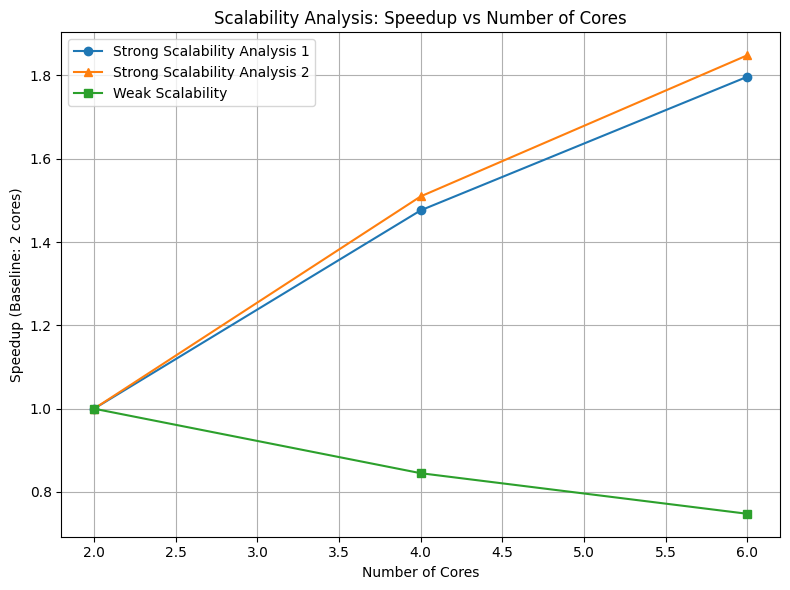

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Data for strong scalability experiment 1
cores = np.array([2, 4, 6])
time_strong1 = np.array([125.88, 85.27, 70.05])
speedup_strong1 = time_strong1[0] / time_strong1

# Data for weak scalability experiment
time_weak = np.array([68.21, 80.71, 91.23])
speedup_weak = time_weak[0] / time_weak

# Data for strong scalability experiment 2
time_strong2 = np.array([105.59, 69.94, 57.12])
speedup_strong2 = time_strong2[0] / time_strong2

plt.figure(figsize=(8, 6))
plt.plot(cores, speedup_strong1, marker='o', linestyle='-', label='Strong Scalability Analysis 1')
plt.plot(cores, speedup_strong2, marker='^', linestyle='-', label='Strong Scalability Analysis 2')
plt.plot(cores, speedup_weak, marker='s', linestyle='-', label='Weak Scalability')

plt.xlabel('Number of Cores')
plt.ylabel('Speedup (Baseline: 2 cores)')
plt.title('Scalability Analysis: Speedup vs Number of Cores')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("scalability_speedup.png")
plt.show()
